# UniverSeg - Evaluation on Our Dataset

In [71]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
from UniverSeg.universeg import universeg
import sys
import itertools
from liver_metastasis_dataset import LiverTumorsDataset
import math
import matplotlib.pyplot as plt
import einops as E
import numpy as np
from tqdm import tqdm
from collections import defaultdict
import pandas as pd
sys.path.append("/cs/casmip/alina.ryabtsev/Tools")
from CalculateMeasures import calculate_measures_dataframe

In [37]:
%reload_ext autoreload
%autoreload 2

In [2]:
sys.path.append('UniverSeg')

First we will load the model and the dataset.

In [3]:
model = universeg(pretrained=True)
_ = model.to(device)
print(f"Running on device: {device}")

Running on device: cuda


We create a split of support and query images from the liver tumors dataset. Let's initialize K to be 10.

In [4]:
d_support = LiverTumorsDataset(split="support", label=1)
d_query = LiverTumorsDataset(split="query", label=1)
K = 10  # number of shots in support

100%|██████████| 109/109 [01:39<00:00,  1.09it/s]


In [5]:
support_images, support_labels = zip(*itertools.islice(d_support, K))
support_images = torch.stack(support_images).to(device)
support_labels = torch.stack(support_labels).to(device)

Now we will add some helper functions to visualize data and evaluate the model.

In [9]:
def visualize_tensors(tensors: torch.tensor, col_wrap: int=8, col_names: str=None, title: str=None):
    M = len(tensors)
    N = len(next(iter(tensors.values())))

    cols = col_wrap
    rows = math.ceil(N/cols) * M

    d = 2.5
    fig, axes = plt.subplots(rows, cols, figsize=(d*cols, d*rows))
    if rows == 1:
      axes = axes.reshape(1, cols)

    for g, (grp, tensors) in enumerate(tensors.items()):
        for k, tensor in enumerate(tensors):
            col = k % cols
            row = g + M*(k//cols)
            x = tensor.detach().cpu().numpy().squeeze()
            ax = axes[row,col]
            if len(x.shape) == 2:
                ax.imshow(x,vmin=0, vmax=1, cmap='gray')
            else:
                ax.imshow(E.rearrange(x,'C H W -> H W C'))
            if col == 0:
                ax.set_ylabel(grp, fontsize=16)
            if col_names is not None and row == 0:
                ax.set_title(col_names[col])

    for i in range(rows):
        for j in range(cols):
            ax = axes[i,j]
            ax.grid(False)
            ax.set_xticks([])
            ax.set_yticks([])

    if title:
        plt.suptitle(title, fontsize=20)

    plt.tight_layout()

In [8]:
# Dice metric for measuring volume agreement
def dice_score(y_pred: torch.Tensor, y_true: torch.Tensor) -> float:
    y_pred = y_pred.long()
    y_true = y_true.long()
    score = 2*(y_pred*y_true).sum() / (y_pred.sum() + y_true.sum())
    return score.item()

In [7]:
# run inference and compute losses for one test image
@torch.no_grad()
def inference(model, image, label, support_images, support_labels):
    image, label = image.to(device), label.to(device)

    # inference
    logits = model(
        image[None],
        support_images[None],
        support_labels[None]
    )[0] # outputs are logits

    soft_pred = torch.sigmoid(logits)
    hard_pred = soft_pred.round().clip(0,1)

    #  score
    score = dice_score(hard_pred, label)

    # return a dictionary of all relevant variables
    return {'Image': image,
            'Soft Prediction': soft_pred,
            'Prediction': hard_pred,
            'Ground Truth': label,
            'score': score}

Now we would like to visualize the samples of the support set

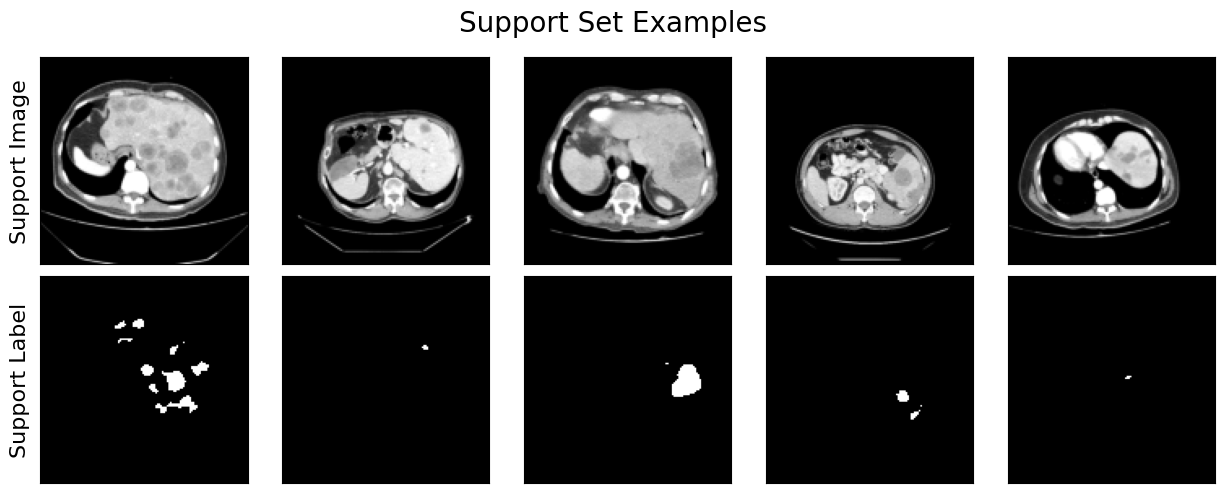

In [9]:
rng = range(95,100)
support_images, support_labels = [d_support[i][0] for i in rng], [d_support[i][1] for i in rng]
n_viz = 5
visualize_tensors({
    'Support Image': support_images[:n_viz],
    'Support Label': support_labels[:n_viz],
}, col_wrap=5, title='Support Set Examples')

Now we will run the inference model on the query images

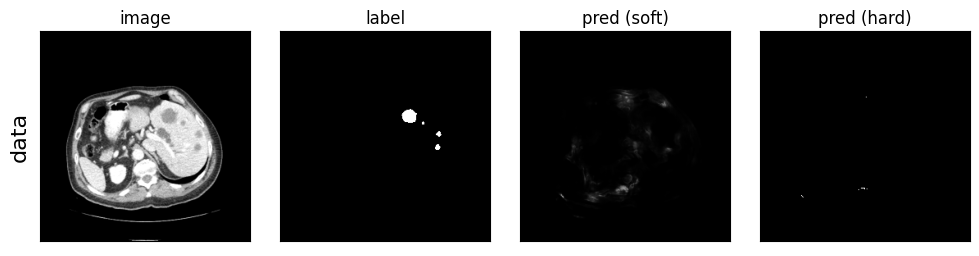

In [8]:
# select an image, label test pair
idx = np.random.permutation(len(d_query))[0]
image, label = d_query[idx]
image, label = image.to(device), label.to(device)

# run inference
logits = model(image[None], support_images[None], support_labels[None])[0].to(device)
pred = torch.sigmoid(logits)

# visualize
res = {'data': [image, label, pred, pred > 0.5]}
titles = col_names=['image', 'label', 'pred (soft)', 'pred (hard)']
visualize_tensors(res, col_wrap=4, col_names=titles)

Now we will try the same process as above with different K

In [8]:
K = 5
support_images, support_labels = zip(*itertools.islice(d_support, K))
support_images = torch.stack(support_images).to(device)
support_labels = torch.stack(support_labels).to(device)

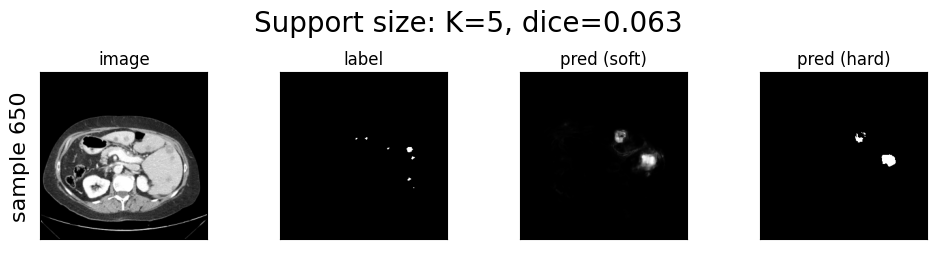

In [12]:
# select an image, label test pair
# idx = np.random.permutation(len(d_query))[0]
idx = 650
image, label = d_query[idx]
image, label = image.to(device), label.to(device)

# run inference
logits = model(image[None], support_images[None], support_labels[None])[0].to(device)
pred = torch.sigmoid(logits)

# visualize
hard_pred = pred > 0.5
dice = np.round(dice_score(hard_pred, label), 3)
res = {f'sample {idx}': [image, label, pred, hard_pred]}
titles = col_names=['image', 'label', 'pred (soft)', 'pred (hard)']
visualize_tensors(res, col_wrap=4, title=f"Support size: K={K}, dice={dice}", col_names=titles)

In [13]:
K = 10
support_images, support_labels = zip(*itertools.islice(d_support, K))
support_images = torch.stack(support_images).to(device)
support_labels = torch.stack(support_labels).to(device)

In [ ]:
# select an image, label test pair
# idx = np.random.permutation(len(d_query))[0]
idx = 650
image, label = d_query[idx]
image, label = image.to(device), label.to(device)

# run inference
logits = model(image[None], support_images[None], support_labels[None])[0].to(device)
pred = torch.sigmoid(logits)

# visualize
hard_pred = pred > 0.5
dice = np.round(dice_score(hard_pred, label), 3)
res = {f'sample {idx}': [image, label, pred, hard_pred]}
titles = col_names=['image', 'label', 'pred (soft)', 'pred (hard)']
visualize_tensors(res, col_wrap=4, title=f"Support size: K={K}, dice={dice}", col_names=titles)

In [15]:
K = 16
support_images, support_labels = zip(*itertools.islice(d_support, K))
support_images = torch.stack(support_images).to(device)
support_labels = torch.stack(support_labels).to(device)

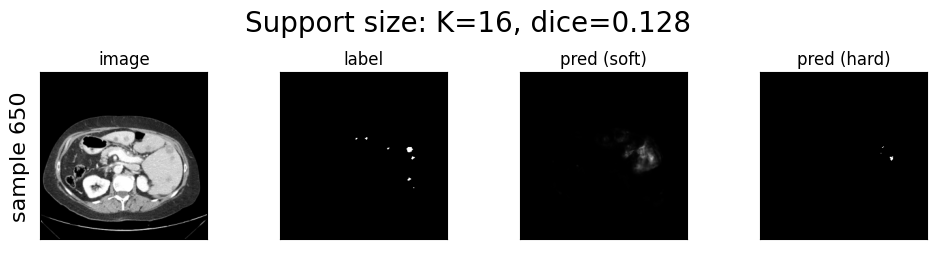

In [16]:
# select an image, label test pair
# idx = np.random.permutation(len(d_query))[0]
idx = 650
image, label = d_query[idx]
image, label = image.to(device), label.to(device)

# run inference
logits = model(image[None], support_images[None], support_labels[None])[0].to(device)
pred = torch.sigmoid(logits)

# visualize
hard_pred = pred > 0.5
dice = np.round(dice_score(hard_pred, label), 3)
res = {f'sample {idx}': [image, label, pred, hard_pred]}
titles = col_names=['image', 'label', 'pred (soft)', 'pred (hard)']
visualize_tensors(res, col_wrap=4, title=f"Support size: K={K}, dice={dice}", col_names=titles)

In [17]:
K = 20
support_images, support_labels = zip(*itertools.islice(d_support, K))
support_images = torch.stack(support_images).to(device)
support_labels = torch.stack(support_labels).to(device)

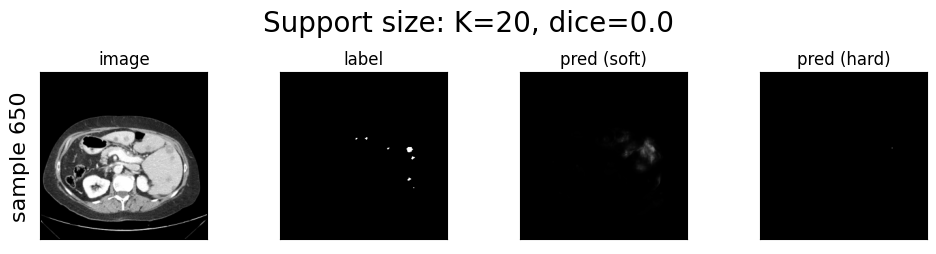

In [18]:
# select an image, label test pair
# idx = np.random.permutation(len(d_query))[0]
idx = 650
image, label = d_query[idx]
image, label = image.to(device), label.to(device)

# run inference
logits = model(image[None], support_images[None], support_labels[None])[0].to(device)
pred = torch.sigmoid(logits)

# visualize
hard_pred = pred > 0.5
dice = np.round(dice_score(hard_pred, label), 3)
res = {f'sample {idx}': [image, label, pred, hard_pred]}
titles = col_names=['image', 'label', 'pred (soft)', 'pred (hard)']
visualize_tensors(res, col_wrap=4, title=f"Support size: K={K}, dice={dice}", col_names=titles)

In [19]:
K = 48
support_images, support_labels = zip(*itertools.islice(d_support, K))
support_images = torch.stack(support_images).to(device)
support_labels = torch.stack(support_labels).to(device)

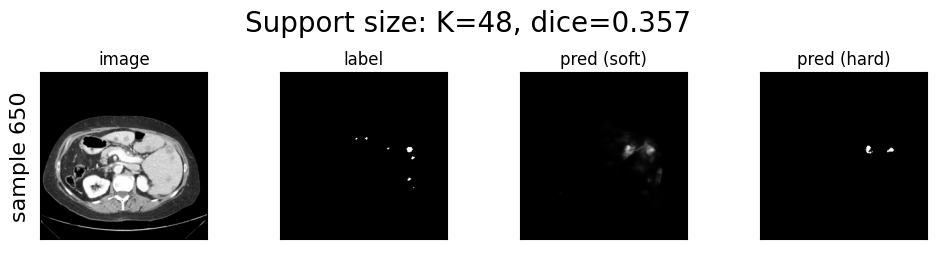

In [20]:
# select an image, label test pair
# idx = np.random.permutation(len(d_query))[0]
idx = 650
image, label = d_query[idx]
image, label = image.to(device), label.to(device)

# run inference
logits = model(image[None], support_images[None], support_labels[None])[0].to(device)
pred = torch.sigmoid(logits)

# visualize
hard_pred = pred > 0.5
dice = np.round(dice_score(hard_pred, label), 3)
res = {f'sample {idx}': [image, label, pred, hard_pred]}
titles = col_names=['image', 'label', 'pred (soft)', 'pred (hard)']
visualize_tensors(res, col_wrap=4, title=f"Support size: K={K}, dice={dice}", col_names=titles)

Now we would like to have only images with actual segmentations in the support set

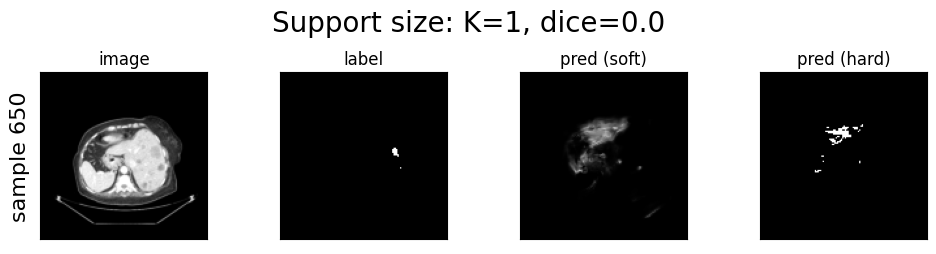

In [11]:
K = 1
support_images, support_labels = zip(*itertools.islice(d_support, K))
support_images = torch.stack(support_images).to(device)
support_labels = torch.stack(support_labels).to(device)
# select an image, label test pair
# idx = np.random.permutation(len(d_query))[0]
idx = 650
image, label = d_query[idx]
image, label = image.to(device), label.to(device)

# run inference
logits = model(image[None], support_images[None], support_labels[None])[0].to(device)
pred = torch.sigmoid(logits)

# visualize
hard_pred = pred > 0.5
dice = np.round(dice_score(hard_pred, label), 3)
res = {f'sample {idx}': [image, label, pred, hard_pred]}
titles = col_names = ['image', 'label', 'pred (soft)', 'pred (hard)']
visualize_tensors(res, col_wrap=4, title=f"Support size: K={K}, dice={dice}", col_names=titles)

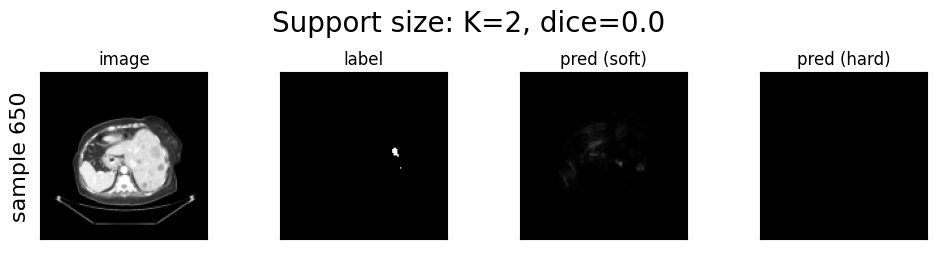

In [12]:
K = 2
support_images, support_labels = zip(*itertools.islice(d_support, K))
support_images = torch.stack(support_images).to(device)
support_labels = torch.stack(support_labels).to(device)
# select an image, label test pair
# idx = np.random.permutation(len(d_query))[0]
idx = 650
image, label = d_query[idx]
image, label = image.to(device), label.to(device)

# run inference
logits = model(image[None], support_images[None], support_labels[None])[0].to(device)
pred = torch.sigmoid(logits)

# visualize
hard_pred = pred > 0.5
dice = np.round(dice_score(hard_pred, label), 3)
res = {f'sample {idx}': [image, label, pred, hard_pred]}
titles = col_names = ['image', 'label', 'pred (soft)', 'pred (hard)']
visualize_tensors(res, col_wrap=4, title=f"Support size: K={K}, dice={dice}", col_names=titles)

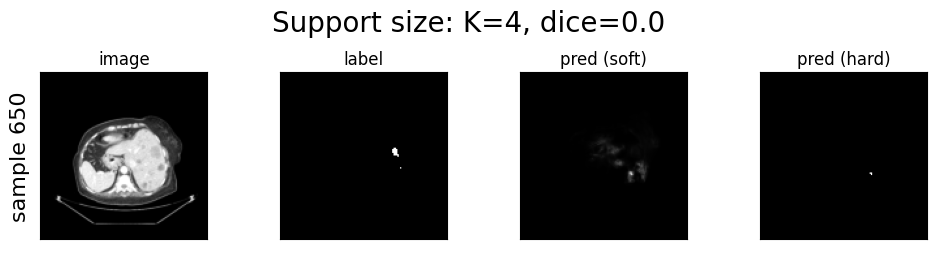

In [13]:
K = 4
support_images, support_labels = zip(*itertools.islice(d_support, K))
support_images = torch.stack(support_images).to(device)
support_labels = torch.stack(support_labels).to(device)
# select an image, label test pair
# idx = np.random.permutation(len(d_query))[0]
idx = 650
image, label = d_query[idx]
image, label = image.to(device), label.to(device)

# run inference
logits = model(image[None], support_images[None], support_labels[None])[0].to(device)
pred = torch.sigmoid(logits)

# visualize
hard_pred = pred > 0.5
dice = np.round(dice_score(hard_pred, label), 3)
res = {f'sample {idx}': [image, label, pred, hard_pred]}
titles = col_names = ['image', 'label', 'pred (soft)', 'pred (hard)']
visualize_tensors(res, col_wrap=4, title=f"Support size: K={K}, dice={dice}", col_names=titles)

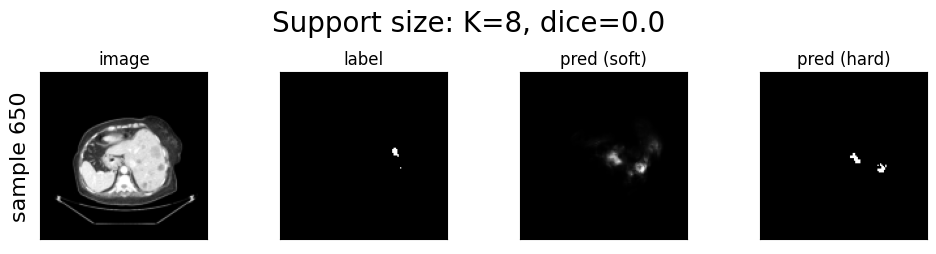

In [14]:
K = 8
support_images, support_labels = zip(*itertools.islice(d_support, K))
support_images = torch.stack(support_images).to(device)
support_labels = torch.stack(support_labels).to(device)
# select an image, label test pair
# idx = np.random.permutation(len(d_query))[0]
idx = 650
image, label = d_query[idx]
image, label = image.to(device), label.to(device)

# run inference
logits = model(image[None], support_images[None], support_labels[None])[0].to(device)
pred = torch.sigmoid(logits)

# visualize
hard_pred = pred > 0.5
dice = np.round(dice_score(hard_pred, label), 3)
res = {f'sample {idx}': [image, label, pred, hard_pred]}
titles = col_names = ['image', 'label', 'pred (soft)', 'pred (hard)']
visualize_tensors(res, col_wrap=4, title=f"Support size: K={K}, dice={dice}", col_names=titles)

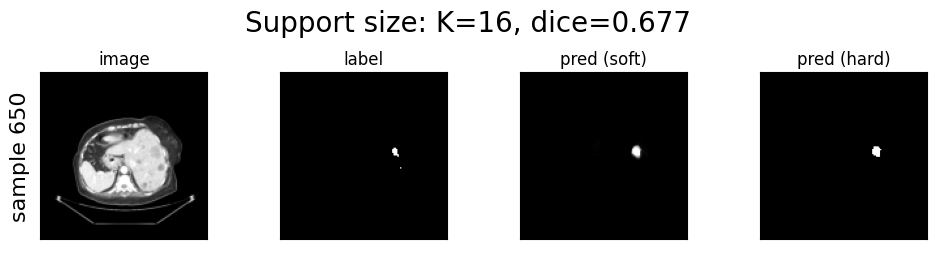

In [15]:
K = 16
support_images, support_labels = zip(*itertools.islice(d_support, K))
support_images = torch.stack(support_images).to(device)
support_labels = torch.stack(support_labels).to(device)
# select an image, label test pair
# idx = np.random.permutation(len(d_query))[0]
idx = 650
image, label = d_query[idx]
image, label = image.to(device), label.to(device)

# run inference
logits = model(image[None], support_images[None], support_labels[None])[0].to(device)
pred = torch.sigmoid(logits)

# visualize
hard_pred = pred > 0.5
dice = np.round(dice_score(hard_pred, label), 3)
res = {f'sample {idx}': [image, label, pred, hard_pred]}
titles = col_names = ['image', 'label', 'pred (soft)', 'pred (hard)']
visualize_tensors(res, col_wrap=4, title=f"Support size: K={K}, dice={dice}", col_names=titles)

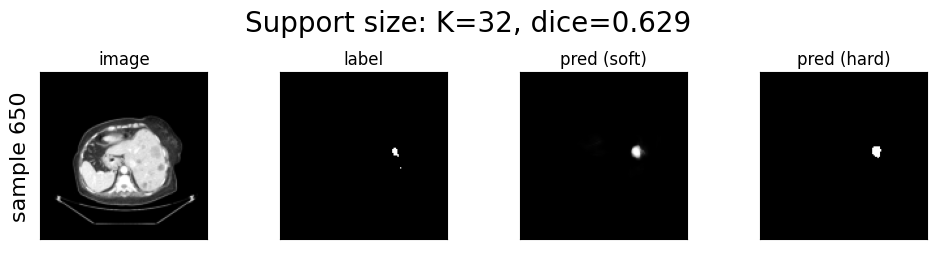

In [16]:
K = 32
support_images, support_labels = zip(*itertools.islice(d_support, K))
support_images = torch.stack(support_images).to(device)
support_labels = torch.stack(support_labels).to(device)
# select an image, label test pair
# idx = np.random.permutation(len(d_query))[0]
idx = 650
image, label = d_query[idx]
image, label = image.to(device), label.to(device)

# run inference
logits = model(image[None], support_images[None], support_labels[None])[0].to(device)
pred = torch.sigmoid(logits)

# visualize
hard_pred = pred > 0.5
dice = np.round(dice_score(hard_pred, label), 3)
res = {f'sample {idx}': [image, label, pred, hard_pred]}
titles = col_names = ['image', 'label', 'pred (soft)', 'pred (hard)']
visualize_tensors(res, col_wrap=4, title=f"Support size: K={K}, dice={dice}", col_names=titles)

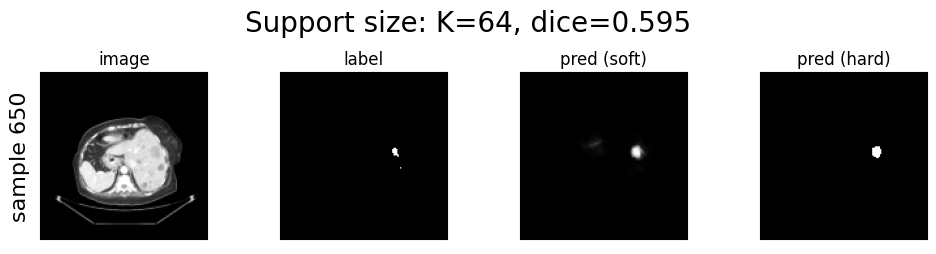

In [17]:
K = 64
support_images, support_labels = zip(*itertools.islice(d_support, K))
support_images = torch.stack(support_images).to(device)
support_labels = torch.stack(support_labels).to(device)
# select an image, label test pair
# idx = np.random.permutation(len(d_query))[0]
idx = 650
image, label = d_query[idx]
image, label = image.to(device), label.to(device)

# run inference
logits = model(image[None], support_images[None], support_labels[None])[0].to(device)
pred = torch.sigmoid(logits)

# visualize
hard_pred = pred > 0.5
dice = np.round(dice_score(hard_pred, label), 3)
res = {f'sample {idx}': [image, label, pred, hard_pred]}
titles = col_names = ['image', 'label', 'pred (soft)', 'pred (hard)']
visualize_tensors(res, col_wrap=4, title=f"Support size: K={K}, dice={dice}", col_names=titles)

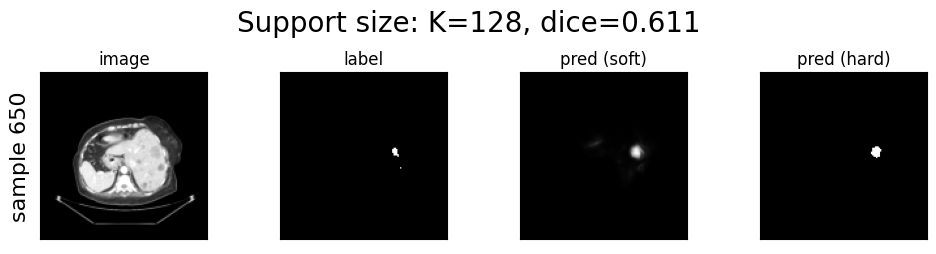

In [18]:
K = 128
support_images, support_labels = zip(*itertools.islice(d_support, K))
support_images = torch.stack(support_images).to(device)
support_labels = torch.stack(support_labels).to(device)
# select an image, label test pair
# idx = np.random.permutation(len(d_query))[0]
idx = 650
image, label = d_query[idx]
image, label = image.to(device), label.to(device)

# run inference
logits = model(image[None], support_images[None], support_labels[None])[0].to(device)
pred = torch.sigmoid(logits)

# visualize
hard_pred = pred > 0.5
dice = np.round(dice_score(hard_pred, label), 3)
res = {f'sample {idx}': [image, label, pred, hard_pred]}
titles = col_names = ['image', 'label', 'pred (soft)', 'pred (hard)']
visualize_tensors(res, col_wrap=4, title=f"Support size: K={K}, dice={dice}", col_names=titles)

Now we would like to calculate some stats over all query images

In [5]:
K = 32
support_images, support_labels = zip(*itertools.islice(d_support, K))
support_images = torch.stack(support_images).to(device)
support_labels = torch.stack(support_labels).to(device)

100%|██████████| 10/10 [00:00<00:00, 43.81it/s]


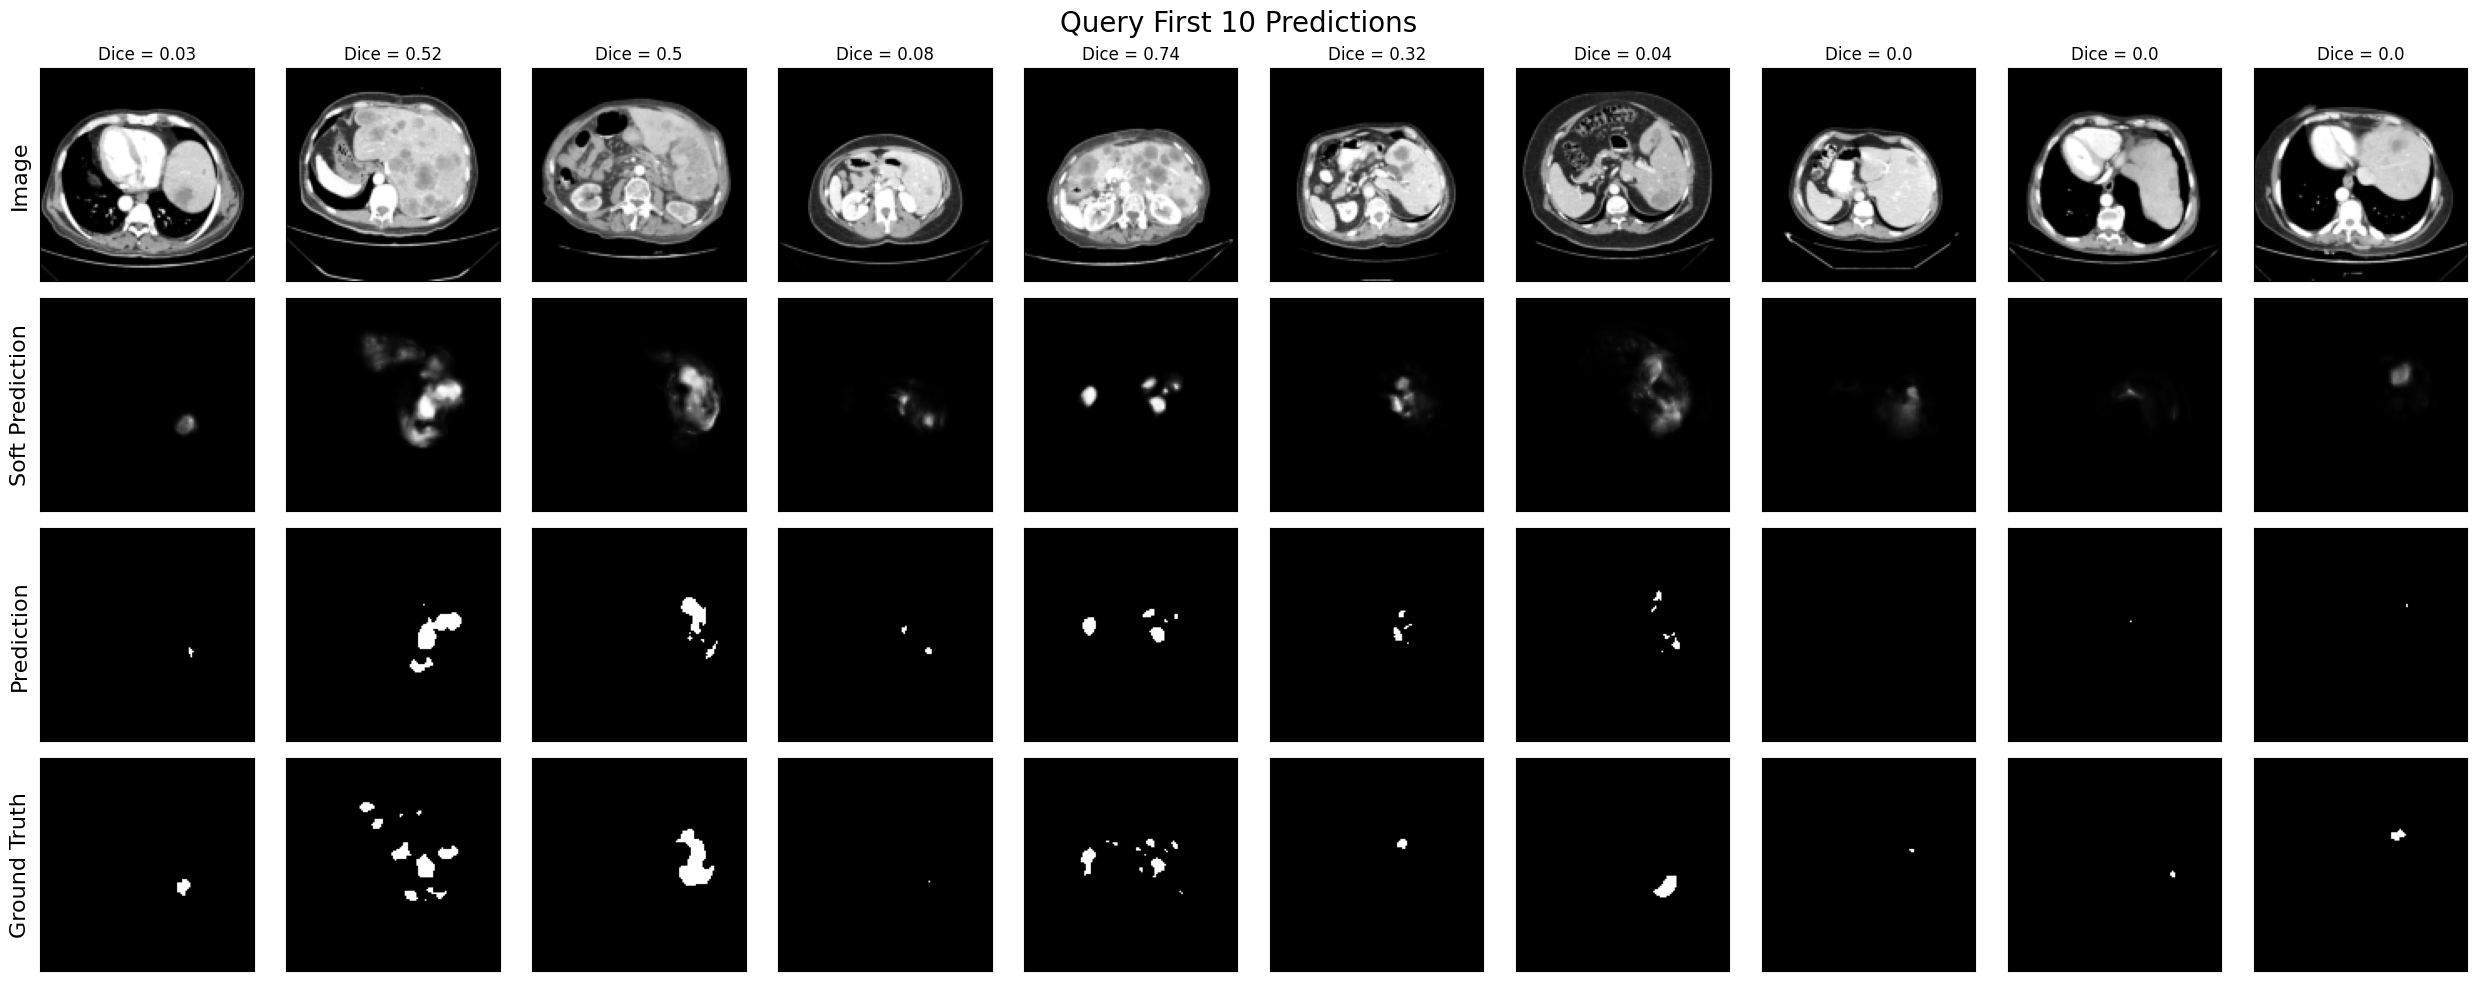

In [32]:
# plot 10 random query images
n_predictions = len(d_query)
results = defaultdict(list)

# compute inference and save predictions and Dice metrics for n_predictions.
idxs = np.random.permutation(n_predictions)[:10]

for i in tqdm(idxs):
    image, label = d_query[i]
    vals = inference(model, image, label, support_images, support_labels)
    for k, v in vals.items():
        results[k].append(v)

# visualize the results, along with their scores
n_present = 10
scores = results.pop('score')
visualize_tensors(results,
                  col_names=[f'Dice = {np.round(s,2)}' for s in scores][:n_present],
                  title=f'Query First {n_present} Predictions',
                  col_wrap=n_present)

In [56]:
n_predictions = len(d_query)
results = defaultdict(list)

# compute inference and save predictions and Dice metrics for n_predictions.

for i in tqdm(range(n_predictions)):
    image, label = d_query[i]
    vals = inference(model, image, label, support_images, support_labels)
    for k, v in vals.items():
        results[k].append(v)

# visualize the results, along with their scores
n_present = 10
scores = results.pop('score')
scores_series = pd.Series(scores)
scores_series.describe()

100%|██████████| 665/665 [00:13<00:00, 48.42it/s]


count    665.000000
mean       0.258805
std        0.282814
min        0.000000
25%        0.000000
50%        0.142857
75%        0.527869
max        0.892857
dtype: float64

### Conclusions so Far:
1. When having support and query slices with tumors, we get some reasonable signal, as even the third quarter of images obtain Dice score higher than 0.52. The support size is 32 although there are 1551 images in the support dataset overall. Every scan in overall has an average of 30-50 slices with 10 slices of tumors in average. Hence - using support set of only 32 slices is like using 3 scans in support, ot of 70+ scans that are in the split of the support set.
2. We should run precision and recall analysis.
3. Make the query dataset organized, containing negative samples (i.e., do not contain any tumors within slices). Transform back to 3D image?

Now we will calculate all measures of the query images:

In [57]:
predictions = [r.cpu().detach().numpy() for r in results["Prediction"]]
gt = [r.cpu().detach().numpy() for r in results["Ground Truth"]]

In [72]:
results_detection = calculate_measures_dataframe("tumors", predictions, gt, range(1, 2), pix_dim=True)[1]

Calculating measures for threshold 1
Setting pixel dimensions to (1,1,1)


100%|██████████| 665/665 [00:00<00:00, 2928.91it/s]


[({'Filename': 'scan', 'Num of lesion': 1, 'Dice': 0.729, 'Dice with FN': 0.729, 'Segmentation TP (cc)': 0.086, 'Segmentation FP (cc)': 0.0, 'Segmentation FN (cc)': 0.064, 'Total tumor volume GT (cc)': 0.15, 'Total tumor volume Predictions (cc)': 0.086, 'Delta between total tumor volumes (cc)': 0.064, 'Delta between total tumor volumes (%)': 27.11864406779661, 'Delta between total tumor volumes (TP only) (cc)': 0.064, 'ABS Delta between total tumor volumes (TP only) (cc)': 0.064, 'Delta between total tumor volumes (TP only) (%)': 27.11864406779661, 'ABS Delta between total tumor volumes (TP only) (%)': 27.11864406779661, 'Tumor Burden GT (%)': 0.8999999999999999, 'Tumor Burden Pred (%)': 0.5, 'Tumor Burden Delta (%)': 0.4, 'Detection TP (per lesion)': 1, 'Detection FP (per lesion)': 0, 'Detection FN (per lesion)': 0, 'Precision': 1.0, 'Recall': 1.0, 'F1 Score': 1.0, 'Mean ASSD (mm)': 0.43, 'Mean Hausdorff (mm)': 5.831, 'Max Hausdorff (mm)': 5.831}, {'Filename': 'scan', 'Num of lesion':

In [76]:
results_detection[0]  # all lesions

,Num of lesion,Dice,Dice with FN,Segmentation TP (cc),Segmentation FP (cc),Segmentation FN (cc),Total tumor volume GT (cc),Total tumor volume Predictions (cc),Delta between total tumor volumes (cc),Delta between total tumor volumes (%),...,Tumor Burden Delta (%),Detection TP (per lesion),Detection FP (per lesion),Detection FN (per lesion),Precision,Recall,F1 Score,Mean ASSD (mm),Mean Hausdorff (mm),Max Hausdorff (mm)
mean,0.756391,0.856308,0.678383,0.041229,0.019809,0.048582,0.089811,0.079388,0.010423,-6.093668,...,0.064962,0.436090,0.371429,0.320301,0.730198,0.789925,0.598774,1.173661,7.166820,7.773795
std,1.018308,0.221485,0.379628,0.096031,0.045646,0.098703,0.155910,0.136856,0.112124,58.941925,...,0.686020,0.712976,0.620019,0.629084,0.424829,0.382639,0.458395,1.446332,5.705428,6.620493
min,0.000000,0.008000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.426000,-100.000000,...,-2.600000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.092000,1.000000,1.000000
max,7.000000,1.000000,1.000000,0.592000,0.302000,0.669000,0.762000,0.745000,0.669000,100.000000,...,4.100000,5.000000,3.000000,5.000000,1.000000,1.000000,1.000000,13.998000,26.173000,35.609000
sum,503.000000,569.445000,451.125000,27.417000,13.173000,32.307000,59.724000,52.793000,6.931000,-4052.289308,...,43.200000,290.000000,247.000000,213.000000,485.582000,525.300000,398.185000,280.505000,1712.870000,1857.937000


In [77]:
results_detection[1]  # lesions greater than 5 mm

,Num of lesion,Dice,Dice with FN,Segmentation TP (cc),Segmentation FP (cc),Segmentation FN (cc),Total tumor volume GT (cc),Total tumor volume Predictions (cc),Delta between total tumor volumes (cc),Delta between total tumor volumes (%),...,Tumor Burden Delta (%),Detection TP (per lesion),Detection FP (per lesion),Detection FN (per lesion),Precision,Recall,F1 Score,Mean ASSD (mm),Mean Hausdorff (mm),Max Hausdorff (mm)
mean,0.299248,0.936347,0.838456,0.034089,0.013802,0.039051,0.073140,0.060334,0.012806,0.815085,...,0.078797,0.195489,0.124812,0.103759,0.892982,0.901755,0.802582,1.192475,8.984050,9.063058
std,0.514034,0.153381,0.315329,0.094646,0.042694,0.097326,0.152307,0.136184,0.110858,44.913913,...,0.677490,0.440062,0.352787,0.324317,0.301875,0.297308,0.393129,1.540958,5.695361,5.656333
min,0.000000,0.008000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.426000,-100.000000,...,-2.600000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.145000,2.000000,2.000000
max,3.000000,1.000000,1.000000,0.592000,0.338000,0.669000,0.713000,0.745000,0.669000,100.000000,...,4.100000,3.000000,2.000000,3.000000,1.000000,1.000000,1.000000,13.998000,24.759000,24.759000
sum,199.000000,622.671000,557.573000,22.669000,9.178000,25.969000,48.638000,40.122000,8.516000,542.031805,...,52.400000,130.000000,83.000000,69.000000,593.833000,599.667000,533.717000,143.097000,1078.086000,1087.567000


In [78]:
results_detection[2]  # lesions greater than 10 mm

,Num of lesion,Dice,Dice with FN,Segmentation TP (cc),Segmentation FP (cc),Segmentation FN (cc),Total tumor volume GT (cc),Total tumor volume Predictions (cc),Delta between total tumor volumes (cc),Delta between total tumor volumes (%),...,Tumor Burden Delta (%),Detection TP (per lesion),Detection FP (per lesion),Detection FN (per lesion),Precision,Recall,F1 Score,Mean ASSD (mm),Mean Hausdorff (mm),Max Hausdorff (mm)
mean,0.036090,0.996717,0.977168,0.008395,0.002421,0.013674,0.022069,0.015439,0.006630,1.145695,...,0.041053,0.016541,0.007519,0.019549,0.992481,0.980451,0.972932,0.570545,7.976818,7.976818
std,0.186655,0.026588,0.140620,0.065282,0.019118,0.086670,0.114585,0.098943,0.102118,16.444917,...,0.623473,0.127641,0.086449,0.138548,0.086449,0.138548,0.162403,0.438696,3.899860,3.899860
min,0.000000,0.716000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.726000,-100.000000,...,-4.400000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.161000,3.162000,3.162000
max,1.000000,1.000000,1.000000,0.592000,0.196000,0.713000,0.713000,0.745000,0.713000,100.000000,...,4.400000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.334000,14.142000,14.142000
sum,24.000000,662.817000,649.817000,5.583000,1.610000,9.093000,14.676000,10.267000,4.409000,761.887317,...,27.300000,11.000000,5.000000,13.000000,660.000000,652.000000,647.000000,6.276000,87.745000,87.745000
